# NanoInspect: Edge-First Visual Quality Inspection on the HP ZGX Nano

**Every part inspected on the line. Only the hard cases leave the building.**

## Problem
At the end of a production line, a QC supervisor has about one second per part to decide: ship it, scrap it, or check it again.
- **Cloud AI** sends every product image off-site, adds a network round-trip to a hard time budget, stops when the WAN drops, and charges for every part.
- **Human inspection** is slow and inconsistent, and it also costs money for every part.
- **New product lines** have hundreds of good images and only a handful of defective ones.
- **A score is not a decision.** Operators need to know *what* is wrong and *where*, and they need an audit trail.

## The system: a cascade of two locally served LLMs, and a human only when it pays
| Tier | Where | Model | Sees | Why this model |
|---|---|---|---|---|
| 1 (cheap) | Nano, vLLM | **Qwen2.5-VL-7B + LoRA fine-tuned on the Nano** | every part | small and fast; fine-tuning makes it a specialist |
| 2 (expensive) | Nano, vLLM | **Qwen3.8-27B NVFP4**, verified for DGX Spark (GB10) in the vLLM recipes | parts tier 1 is not sure about, plus a 5% audit of accepts | 4× larger; compares the part with a known-good reference image and explains |
| 3 | Cloud | a human reviewer (no AI in the cloud) | only when review is cheaper than the risk of an automatic mistake | |

The escalation rule is explicit, defensible and measurable: section 6.

## Baselines we compare against
1. **Classical classifier (not an LLM):** ResNet-18, one per product, trained on the Nano (good images, synthetic defects and half of the real defects).
2. **Training-free delta (not an LLM):** per-patch distance to the nearest patch of ~40 known-good parts. This is how the "delta between good and bad" is measured explicitly, and it also draws the heatmap in the app.
3. **Zero-shot Qwen2.5-VL-7B:** the tier-1 model without our fine-tuning.
4. **Zero-shot Qwen3.8-27B:** the big model alone, one image, no reference.
5. **Business baselines:** a human checks every part; tier 1 decides alone; tier 2 decides alone.

Every evaluation uses held-out images: half of each real defect type plus all good test images. None of them was used for training.

In [1]:
# Setup: both models must be served (./serve_models.sh both) before running this notebook
%load_ext autoreload
%autoreload 2
import sys, os, json, time, random
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from nanoinspect import config, data, serving, cascade, policy, telemetry, stress_llm, vision
from nanoinspect.linesim import LineSimulator
from nanoinspect.config import CATEGORIES, RESULTS_DIR

config.ensure_dirs()
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 220)
SOAK_MINUTES = float(os.environ.get("NANOINSPECT_SOAK_MINUTES", 15))
BENCH = {}
t1, t2 = serving.tier1(), serving.tier2()
props = torch.cuda.get_device_properties(0)
BENCH["hardware"] = {"gpu": props.name, "unified_memory_gb": round(props.total_memory / 1e9, 1), "cpu_cores": os.cpu_count()}
print(BENCH["hardware"])
print("Tier 1 served at", t1.url, "healthy:", t1.healthy(), "| Tier 2 served at", t2.url, "healthy:", t2.healthy())
print("GPU processes:", telemetry.other_gpu_processes())
assert t1.healthy() and t2.healthy(), "Start the models first: ./serve_models.sh both"

{'gpu': 'NVIDIA GB10', 'unified_memory_gb': 130.6, 'cpu_cores': 20}
Tier 1 served at http://127.0.0.1:8001 healthy: True | Tier 2 served at http://127.0.0.1:8002 healthy: True
GPU processes: ['2783411, /home/hp14/jupyterlab/.venv/bin/python3', '3103428, VLLM::EngineCore', '3185062, VLLM::EngineCore']


## 1. Choosing the models: the vLLM recipes for DGX Spark (GB10)

The ZGX Nano uses the same GB10 chip as the DGX Spark. The [vLLM recipes](https://recipes.vllm.ai) list which models are *verified* on it. A snapshot of that list is saved in `docs/vllm_recipes_dgx_spark.json`.

- **Tier 2:** among the verified multimodal models, **Qwen3.8-27B** is a dense 27B vision-language model. Its NVFP4 build is 22 GB, it has recipe flags for GB10, and it is the model the hackathon handout uses as its `zrt serve` example. The MoE options (Qwen3.6-35B-A3B, Gemma-4-26B-A4B) are faster per token but less capable per call. Tier 2 is the "think harder" step, so we chose the dense model.
- **Tier 1:** the cheap tier has to be *fine-tuned on the Nano*. The handout recommends at most 12B BF16 for on-device fine-tuning, and none of the Spark-verified VLMs is that small. So we use Qwen2.5-VL-7B (listed in the vLLM recipes, same family), which fine-tunes with LoRA in under 30 minutes on the Nano and serves with its adapter through vLLM.

In [2]:
rec = json.loads((config.PROJECT_DIR / "docs" / "vllm_recipes_dgx_spark.json").read_text())
spark = pd.DataFrame(rec["dgx_spark_verified_multimodal"])
display(spark[["hf_id", "architecture", "parameters", "active", "dgx_spark_gb10"]].drop_duplicates("hf_id"))
print("Served now:")
for t in (t1, t2):
    print(" ", t.url, [m["id"] for m in t.session.get(f"{t.url}/v1/models").json()["data"]])

,hf_id,architecture,parameters,active,dgx_spark_gb10
0,Google/diffusiongemma-26B-A4B-it,moe,26B,4B,verified
1,Google/gemma-4-26B-A4B-it,moe,26B,4B,verified
2,Lightricks/LTX-2.5-Diffusers,dense,19B,19B,supported
3,MiniMaxAI/MiniMax-H3,dense,64B,64B,verified
4,Qwen/Qwen3.6-27B,dense,27B,27B,verified
5,Qwen/Qwen3.6-35B-A3B,moe,35B,3B,verified
6,Qwen/Qwen3.8-27B,dense,27B,27B,verified
7,meta-models/Muse-Glimmer-30B,dense,29.6B,29.6B,verified
8,RedHatAI/diffusiongemma-26B-A4B-it-FP8-dynamic,moe,26B,4B,verified
9,RedHatAI/diffusiongemma-26B-A4B-it-NVFP4,moe,26B,4B,verified


Served now:
  http://127.0.0.1:8001 ['qwen2.5-vl-7b', 'nanoinspect-7b-lora']
  http://127.0.0.1:8002 ['qwen3.8-27b', 'nanoinspect-27b-lora']


## 2. Data and held-out split

In [3]:
splits = data.make_splits()
display(data.split_summary(splits))
assert not data.leakage_check(splits)
print("Leakage check passed: no evaluation image (by file hash) appears in any training split.")
masks = {c: data.load_cache(c, splits, workers=16)[1] for c in CATEGORIES}
items = cascade.eval_items(splits, masks)
if os.environ.get("NANOINSPECT_QUICK") == "1":            # dry-run mode for development only
    items = random.Random(0).sample(items, 120)
refs = {c: serving.reference_image(splits, c) for c in CATEGORIES}
print(len(items), "evaluation images:", sum(i["label"] == 0 for i in items), "good,", sum(i["label"] for i in items), "defective")

,category,defect_types,fit_good,val_good,defect_fit (A),defect_eval (B),eval_good
0,bottle,3,178,31,31,32,20
1,cable,8,191,33,46,46,58
2,capsule,5,187,32,55,54,23
3,carpet,5,238,42,44,45,28
4,grid,5,225,39,30,27,21
5,hazelnut,4,333,58,34,36,40
6,leather,5,209,36,47,45,32
7,metal_nut,4,187,33,47,46,22
8,pill,7,227,40,69,72,26
9,screw,5,272,48,60,59,41


Leakage check passed: no evaluation image (by file hash) appears in any training split.


1096 evaluation images: 467 good, 629 defective


## 3. Tier 1: fine-tuning Qwen2.5-VL-7B on the Nano (LoRA)

- **Training data (real defects only, no synthetic images):** the split-A real defects (label, defect type from the folder name, location from the ground-truth mask) plus an equal number of good training images: 1,258 examples.
- **Method:** LoRA with rank 16 on the language model's attention and MLP projections; the vision encoder is frozen. About 40M trainable parameters (0.48%), 2 epochs, bf16.
- **Where it runs:** training uses `nanoinspect/vlm.py` (Hugging Face transformers + PEFT) on the Nano, and the adapter is served by vLLM with `--enable-lora`.
- **Default:** it already ran on this Nano (about 28 minutes), so this cell loads its record. Set `RETRAIN = True` to train again; stop the vLLM servers first to free memory.

examples            1.258000e+03
epochs              2.000000e+00
optimizer_steps     3.150000e+02
train_seconds       1.682200e+03
trainable_params    4.037018e+07
total_params        8.332537e+09
trainable_pct       4.840000e-01
lora_rank           1.600000e+01
lr                  1.000000e-04
effective_batch     8.000000e+00
peak_gpu_mem_gb     3.900000e+01
dtype: float64

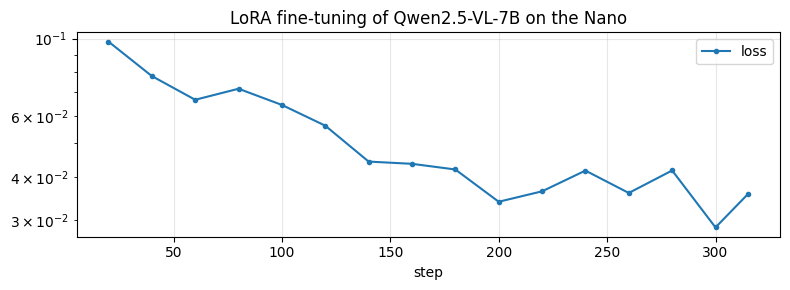

In [4]:
RETRAIN = False
from nanoinspect import vlm
if RETRAIN:
    v = vlm.VLM(); ft_stats, ft_hist = vlm.finetune(v, vlm.finetune_examples(splits, masks), epochs=2)
else:
    saved = json.loads((vlm.ADAPTER_DIR / "training_stats.json").read_text()); ft_stats, ft_hist = saved["stats"], pd.DataFrame(saved["history"])
BENCH["tier1_finetune"] = ft_stats
display(pd.Series(ft_stats))
ax = ft_hist.plot(x="step", y="loss", marker=".", figsize=(8, 3), title="LoRA fine-tuning of Qwen2.5-VL-7B on the Nano"); ax.set_yscale("log")
plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(RESULTS_DIR / "vlm_finetune_loss.png", dpi=110); plt.show()

## 4. Model quality: tiers vs baselines, on the same 1,096 held-out images

Each LLM answers in JSON. We also read the log-probabilities of the verdict token, which gives each model a probability of "defective" and therefore a ROC-AUC comparable with the classical baseline.

In [5]:
configs = [
    ("Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano)", t1, t1.model, False, 32),
    ("Baseline: Qwen2.5-VL-7B zero-shot", t1, serving.TIER1_BASE, False, 32),
    ("Tier 2: Qwen3.8-27B with good reference", t2, t2.model, True, 8),
    ("Baseline: Qwen3.8-27B zero-shot, single image", t2, serving.TIER2_BASE, False, 8),
]
single = serving.Tier("tier2-single", serving.TIER2_URL, serving.TIER2_MODEL, serving.tier1_prompt, n_images=1, max_tokens=60,
                      extra={"chat_template_kwargs": {"enable_thinking": False}})
runs = {}
files = {"Tier 1": "llm_t1_ft.csv", "Baseline: Qwen2.5-VL-7B zero": "llm_t1_zero.csv", "Tier 2": "llm_t2_ref.csv", "Baseline: Qwen3.8-27B": "llm_t2_zero.csv"}
for name, tier, model, ref, workers in configs:
    tr = single if name.startswith("Baseline: Qwen3.8") else tier
    runs[name] = cascade.run_config(name, tr, items, splits, model=model, with_reference=ref, workers=workers)
    for pre, f in files.items():                      # save each model's answers as soon as they exist
        if name.startswith(pre): runs[name].to_csv(RESULTS_DIR / f, index=False)
runs["Baseline: ResNet-18 classifier (non-LLM)"] = cascade.resnet_baseline(pd.read_csv(RESULTS_DIR / "vision_predictions.csv"), items)
# Training-free "delta": per-patch feature distance to the nearest of ~16,000 patches from 40 good parts per product
from nanoinspect.delta import DeltaMap
t0 = time.perf_counter(); DELTA = DeltaMap(splits); dz = np.array([DELTA.score(data.load_pil(it["path"]), it["category"])[2] for it in items])
ddf = pd.DataFrame(items); ddf["p_defective"] = 1 / (1 + np.exp(-(dz - 3))); ddf["verdict"] = np.where(dz >= 3, "defective", "good")
ddf["valid"] = True; ddf["defect_type"] = None; ddf["location"] = None; ddf["latency_s"] = np.nan; ddf.attrs["wall_s"] = time.perf_counter() - t0
runs["Baseline: training-free delta vs good parts (non-LLM)"] = ddf
files = {"Tier 1": "llm_t1_ft.csv", "Baseline: Qwen2.5-VL-7B zero": "llm_t1_zero.csv", "Tier 2": "llm_t2_ref.csv", "Baseline: Qwen3.8-27B": "llm_t2_zero.csv"}
for name, df in runs.items():
    for pre, f in files.items():
        if name.startswith(pre): df.to_csv(RESULTS_DIR / f, index=False)
quality = pd.DataFrame([cascade.summarize(df, name, df.attrs.get("wall_s")) for name, df in runs.items()])
display(quality.round(3))
BENCH["model_quality"] = quality.round(4).replace({np.nan: None}).to_dict("records")

Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano): 1096 images


50/1096 done, 12s

100/1096 done, 23s

150/1096 done, 29s

200/1096 done, 41s

...

950/1096 done, 924s

1000/1096 done, 972s

1050/1096 done, 1019s

1096/1096 done, 1064s


,config,images,roc_auc,accuracy,recall,false_positive_rate,defect_type_acc,location_acc,valid_json_rate,mean_latency_s,throughput_img_per_s
0,Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano),1096,0.962,0.887,0.844,0.056,0.736,0.706,1.0,5.539,5.652
1,Baseline: Qwen2.5-VL-7B zero-shot,1096,0.837,0.538,0.208,0.017,0.527,0.481,1.0,5.057,6.178
2,Tier 2: Qwen3.8-27B with good reference,1096,0.988,0.947,0.943,0.047,0.781,0.808,1.0,15.673,0.505
3,"Baseline: Qwen3.8-27B zero-shot, single image",1096,0.924,0.822,0.747,0.077,0.513,0.643,1.0,7.674,1.030
4,Baseline: ResNet-18 classifier (non-LLM),1096,0.960,0.896,0.928,0.148,NaN,NaN,1.0,NaN,NaN
5,Baseline: training-free delta vs good parts (n...,1096,0.892,0.767,0.625,0.041,NaN,NaN,1.0,NaN,1.605


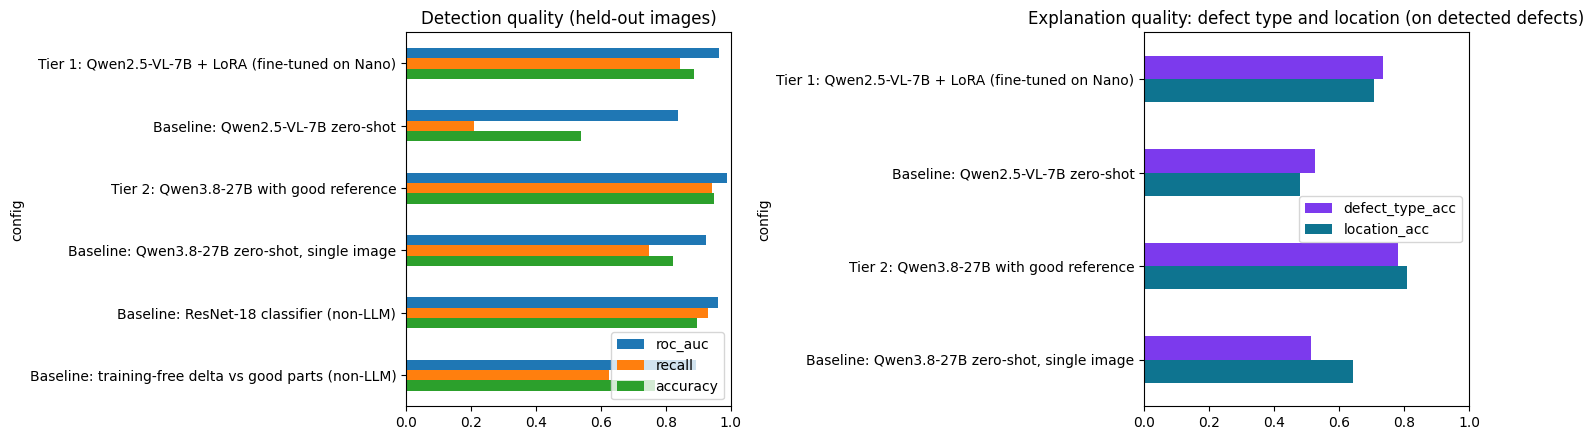

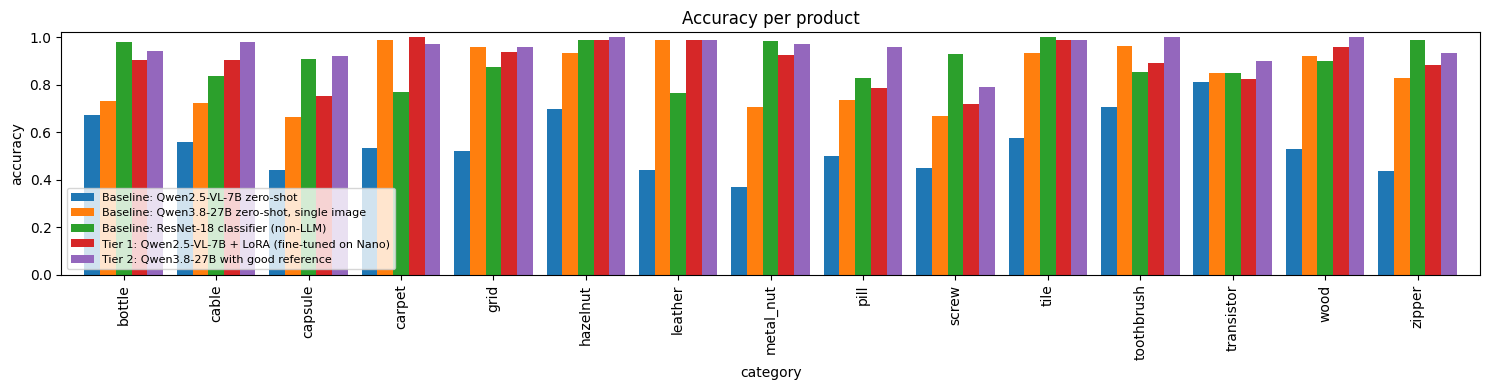

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
q = quality.set_index("config")
q[["roc_auc", "recall", "accuracy"]].plot.barh(ax=ax[0]); ax[0].set_xlim(0, 1); ax[0].invert_yaxis(); ax[0].set_title("Detection quality (held-out images)")
q[["defect_type_acc", "location_acc"]].dropna().plot.barh(ax=ax[1], color=["#7c3aed", "#0e7490"]); ax[1].set_xlim(0, 1); ax[1].invert_yaxis()
ax[1].set_title("Explanation quality: defect type and location (on detected defects)")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "model_quality.png", dpi=110); plt.show()

per_cat = pd.concat(runs.values()).assign(correct=lambda d: (d.verdict == "defective") == (d.label == 1)).groupby(["category", "config"]).correct.mean().unstack()
ax = per_cat.plot.bar(figsize=(15, 4), width=0.85); ax.set_ylim(0, 1.02); ax.set_ylabel("accuracy"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Accuracy per product"); plt.tight_layout(); plt.savefig(RESULTS_DIR / "model_quality_per_category.png", dpi=110); plt.show()

In [7]:
# Tier-1 fast-accept threshold from VALIDATION good parts (never from test images):
# the P(defect) below which 95% of held-out good training images fall, clipped to [0.02, 0.5].
val = cascade.run_config("Tier 1 on validation good parts", t1, cascade.val_good_items(splits), splits, workers=32)
T_LO = float(np.clip(np.quantile(val.p_defective, 0.95), 0.02, 0.5))
BENCH["t_lo"] = T_LO
print(f"Tier-1 fast-accept threshold T_LO = {T_LO:.3f} (from {len(val)} validation good parts)")

Tier 1 on validation good parts: 539 images


50/539 done, 13s

100/539 done, 24s

150/539 done, 30s

200/539 done, 43s

...

350/539 done, 68s

400/539 done, 79s

450/539 done, 91s

500/539 done, 97s

539/539 done, 102s
Tier-1 fast-accept threshold T_LO = 0.500 (from 539 validation good parts)


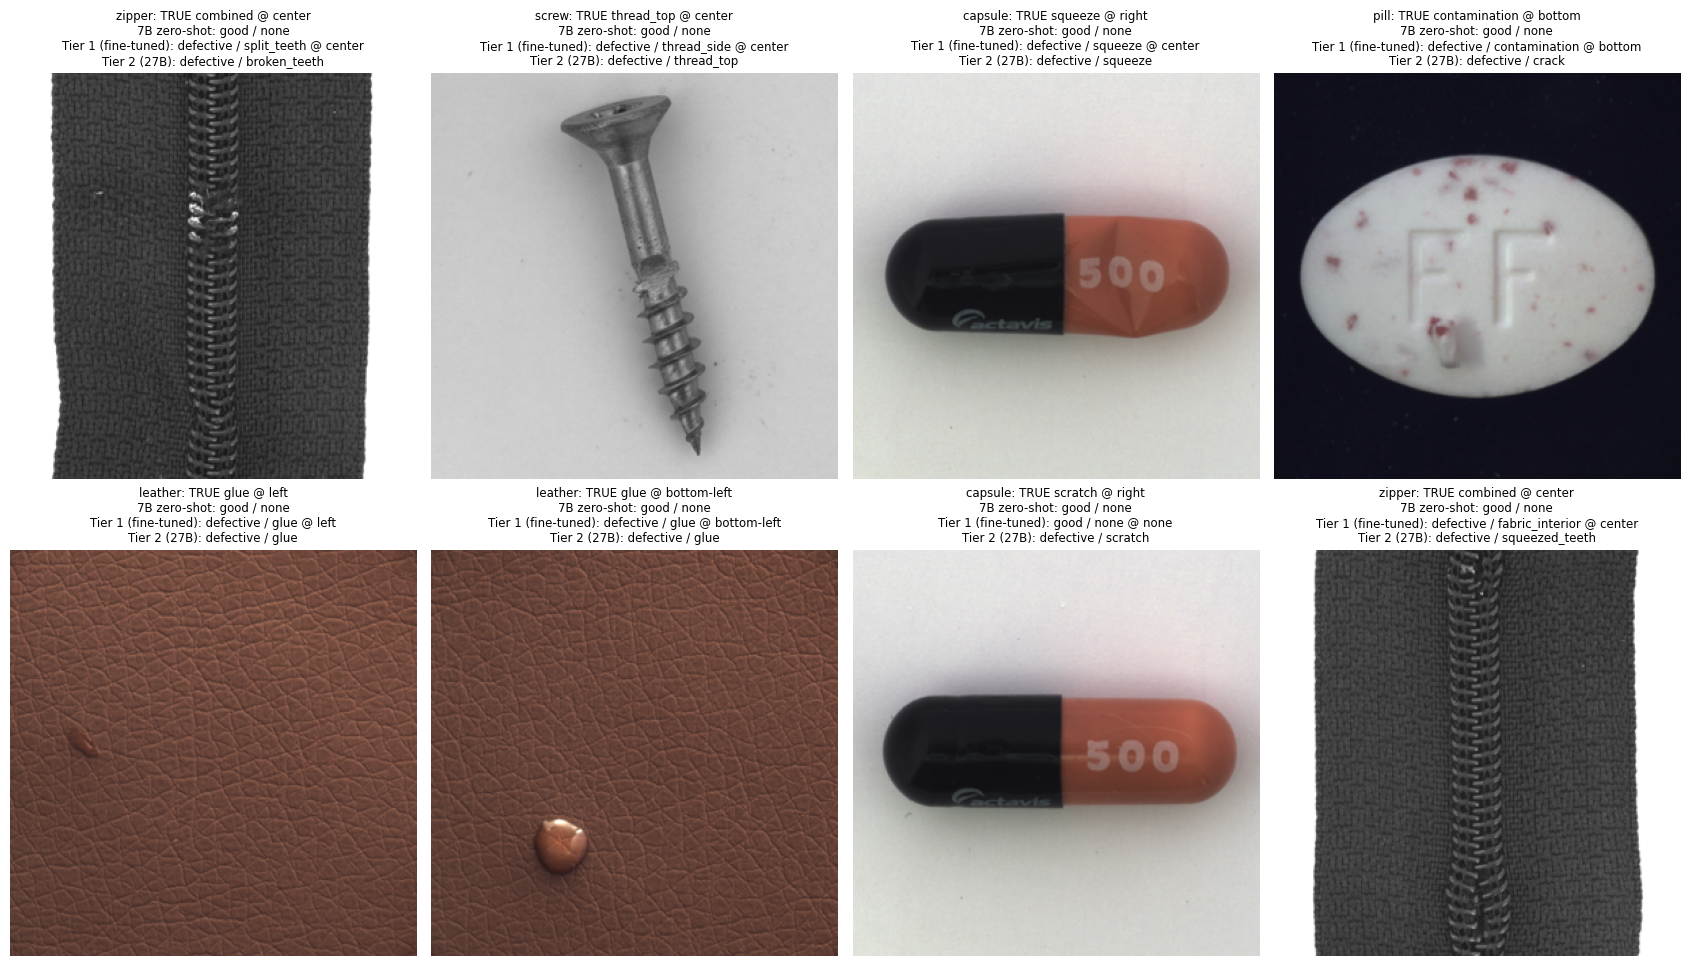

Tier-2 explanations for the same parts:
 - zipper/combined: Visible broken teeth at the center of the part that the reference part does not have.
 - screw/thread_top: Visible thread top at the center of the part that the reference part does not have.
 - capsule/squeeze: Visible squeeze at the right of the part that the reference part does not have.
 - pill/contamination: Visible crack at the bottom of the part that the reference part does not have.
 - leather/glue: Visible glue at the left of the part that the reference part does not have.
 - leather/glue: Visible glue at the bottom-left of the part that the reference part does not have.
 - capsule/scratch: Visible scratch at the right of the part that the reference part does not have.
 - zipper/combined: Visible squeezed teeth at the bottom of the part that the reference part does not have.


In [8]:
# What each model says about the same defects (seeded random sample of held-out defects)
t1d, t2d, zd = (runs[k].set_index("path") for k in ["Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano)", "Tier 2: Qwen3.8-27B with good reference", "Baseline: Qwen2.5-VL-7B zero-shot"])
sample = runs["Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano)"].query("label == 1").sample(8, random_state=3)
fig, ax = plt.subplots(2, 4, figsize=(17, 10))
for a, r in zip(ax.flat, sample.itertuples()):
    a.imshow(data.load_pil(r.path).resize((300, 300))); a.axis("off")
    a.set_title(f"{r.category}: TRUE {r.true_type} @ {r.true_location}\n7B zero-shot: {zd.loc[r.path].verdict} / {zd.loc[r.path].defect_type}\n"
                f"Tier 1 (fine-tuned): {r.verdict} / {r.defect_type} @ {r.location}\nTier 2 (27B): {t2d.loc[r.path].verdict} / {t2d.loc[r.path].defect_type}", fontsize=8.5)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "llm_examples.png", dpi=100); plt.show()
print("Tier-2 explanations for the same parts:")
for r in sample.itertuples(): print(f" - {r.category}/{r.true_type}: {t2d.loc[r.path].explanation}")

## 5. Serving performance on the Nano (vLLM)

These are the model metrics after serving: requests per second, output tokens per second, and p50/p95 latency at increasing numbers of concurrent clients, plus vLLM's own server-side metrics (time to first token, time per output token, KV-cache use).

tier1


,concurrency,requests,wall_s,requests_per_s,output_tokens_per_s,p50_latency_s,p95_latency_s
0,1,64,129.19,0.50,11.6,1.945,2.170
1,4,64,31.07,2.06,48.3,1.804,2.604
2,8,64,18.06,3.54,83.0,2.049,3.120
3,16,64,10.83,5.91,138.5,2.534,3.151
4,32,64,7.66,8.36,195.7,3.607,4.037


tier2


,concurrency,requests,wall_s,requests_per_s,output_tokens_per_s,p50_latency_s,p95_latency_s
0,1,8,94.26,0.08,3.9,11.617,12.413
1,2,8,51.20,0.16,7.2,12.092,13.716
2,4,8,28.20,0.28,13.0,13.305,14.327
3,8,16,34.43,0.46,21.2,16.283,18.175


,requests_running,requests_waiting,kv_cache_usage,prefix_cache_hit_rate,prompt_tokens_total,generation_tokens_total,requests_finished,mean_ttft_s,mean_e2e_s,mean_tpot_s
tier1,0.0,0.0,0.0,0.08487,2083376.0,118880.0,5244.0,1.778994,5.165711,0.156411
tier2,0.0,0.0,0.0,0.00000,2223268.0,153881.0,4436.0,1.366675,11.594885,0.303590


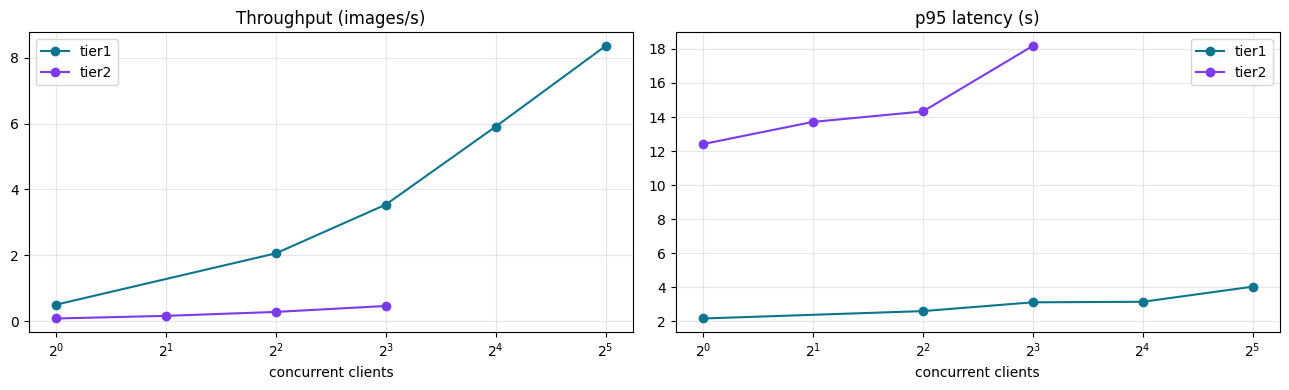

In [9]:
jobs = [([data.load_pil(it["path"])], it["category"]) for it in random.Random(0).sample(items, 64)]
jobs2 = [([refs[c], im[0]], c) for im, c in jobs[:32]]
serve = {"tier1": [serving.load_test(t1, jobs, c) for c in (1, 4, 8, 16, 32)],
         "tier2": [serving.load_test(t2, jobs2[: max(8, 2 * c)], c) for c in (1, 2, 4, 8)]}
BENCH["serving"] = serve
BENCH["serving_server_metrics"] = {"tier1": t1.metrics(), "tier2": t2.metrics()}
for k, v in serve.items(): print(k); display(pd.DataFrame(v))
display(pd.DataFrame(BENCH["serving_server_metrics"]).T)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, col in (("tier1", "#0e7490"), ("tier2", "#7c3aed")):
    d = pd.DataFrame(serve[k])
    ax[0].plot(d.concurrency, d.requests_per_s, "o-", color=col, label=k); ax[1].plot(d.concurrency, d.p95_latency_s, "o-", color=col, label=k)
ax[0].set_title("Throughput (images/s)"); ax[1].set_title("p95 latency (s)")
for a in ax: a.set_xlabel("concurrent clients"); a.set_xscale("log", base=2); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "serving_benchmark.png", dpi=110); plt.show()

## 6. The escalation decision: explicit, defensible, measurable

After both tiers have looked at a part, it lands in an **evidence bucket** (both say good, both say defect, or they disagree). We measure P(bucket | defect) and P(bucket | good) on labelled data. With the line's defect rate π, Bayes' rule gives P(defect | bucket).

**Escalate to a human only if min(P(defect) × cost of an escaped defect, P(good) × cost of scrapping a good part) > cost of one human review.**

- The likelihoods are fitted on a random half of the evaluation images, and all costs are reported on the other half.
- The default costs ($50 per escape, $2 per scrapped part, $0.50 per review, 5% defect rate) are assumptions; the operator changes them in the app.

In [10]:
t1df, t2df = runs["Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano)"], runs["Tier 2: Qwen3.8-27B with good reference"].set_index("path")
res_df = runs["Baseline: ResNet-18 classifier (non-LLM)"].set_index("path"); z27 = runs["Baseline: Qwen3.8-27B zero-shot, single image"].set_index("path")
pdf = t1df[["path", "category", "label"]].copy()
pdf["score"] = t1df.p_defective.values; pdf["review_at"] = T_LO; pdf["verdict"] = pdf.path.map(t2df.verdict)
pdf["resnet_flag"] = pdf.path.map(res_df.p_defective) >= 0.5
pdf["t2_flag"] = pdf.path.map(t2df.verdict) == "defective"; pdf["t2zero_flag"] = pdf.path.map(z27.verdict) == "defective"
COSTS, RATE, AUDIT = dict(policy.DEFAULT_COSTS), policy.DEFAULT_DEFECT_RATE, 0.05
table, held_out, lik = policy.fit_and_save(pdf, costs=COSTS, defect_rate=RATE, audit_rate=AUDIT, t_lo=T_LO,
    extra_baselines={"Tier 2 alone (27B with reference decides)": "t2_flag", "Baseline: 27B zero-shot alone": "t2zero_flag",
                     "Baseline: ResNet-18 alone (non-LLM)": "resnet_flag"})
display(table.drop(columns=["meaning"]).round(4))
display(held_out.round(3).sort_values("cost_per_1000_usd"))
BENCH["escalation_policy"] = {"costs": COSTS, "defect_rate": RATE, "t_lo": T_LO, "held_out": held_out.round(4).to_dict("index"),
                              "table": table[["bucket", "p_defect", "action"]].round(5).to_dict("records")}

,bucket,p_defect,expected_cost_accept_usd,expected_cost_reject_usd,human_review_usd,action,evidence_defect_parts,evidence_good_parts
0,fast_accept,0.0091,0.4555,1.9818,0.5,accept,51,207
1,agree_good,0.0017,0.0843,1.9966,0.5,accept,8,195
2,agree_defect,0.8219,41.0956,0.3562,0.5,reject,250,1
3,t1_flag_t2_good,0.0393,1.9628,1.9215,0.5,escalate_to_human,9,8
4,t1_good_t2_defect,0.1107,5.5345,1.7786,0.5,escalate_to_human,43,12
5,t2_unusable,0.0355,1.7735,1.9291,0.5,escalate_to_human,0,0


,escapes_per_1000,false_rejects_per_1000,vlm_calls_per_1000,human_reviews_per_1000,cost_per_1000_usd
Tier 2 alone (27B with reference decides),2.978,34.064,0.000,0.000,217.030
NanoInspect cascade,7.226,11.355,151.478,55.832,411.910
Baseline: ResNet-18 alone (non-LLM),3.762,128.685,0.000,0.000,445.458
Human inspects every part,0.000,0.000,0.000,1000.000,500.000
Tier 1 alone (fine-tuned 7B decides),7.524,64.343,0.000,0.000,504.861
Baseline: 27B zero-shot alone,12.539,75.697,0.000,0.000,778.354


,escapes_per_1000,false_rejects_per_1000,vlm_calls_per_1000,human_reviews_per_1000,cost_per_1000_usd
"cascade, tier 1 zero-shot",39.459,0.000,65.381,12.244,1979.084
"cascade, tier 1 fine-tuned on Nano",7.226,11.355,151.478,55.832,411.910


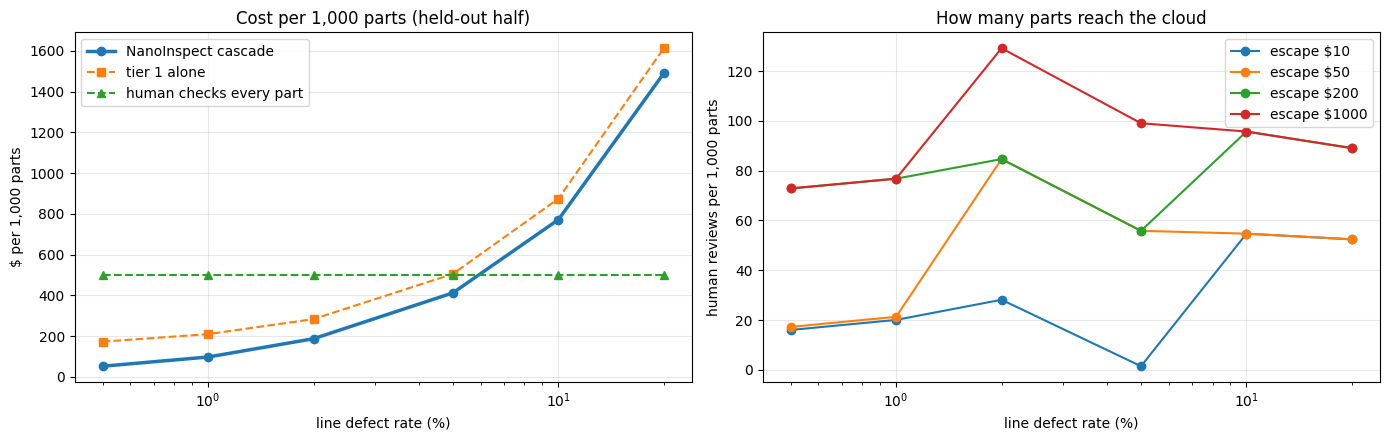

In [11]:
# What fine-tuning is worth: the same cascade with the zero-shot 7B in tier 1
zdf = pdf.copy(); zdf["score"] = zdf.path.map(runs["Baseline: Qwen2.5-VL-7B zero-shot"].set_index("path").p_defective)
m = np.random.default_rng(0).random(len(zdf)) < 0.5
zt = policy.policy_table(policy.fit_likelihoods(zdf[m]), COSTS, RATE)
ft_t = policy.policy_table(policy.fit_likelihoods(pdf[m]), COSTS, RATE)
value = pd.DataFrame({"cascade, tier 1 zero-shot": policy.simulate(zdf[~m], zt, RATE, COSTS, AUDIT),
                      "cascade, tier 1 fine-tuned on Nano": policy.simulate(pdf[~m], ft_t, RATE, COSTS, AUDIT)}).T
display(value.round(3)); BENCH["value_of_finetuning"] = value.round(4).to_dict("index")

# Sensitivity: how the decision moves with the business's numbers
rows = []
for rate in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    for esc_cost in [10, 50, 200, 1000]:
        c = {**COSTS, "escape_usd": esc_cost}; t = policy.policy_table(policy.fit_likelihoods(pdf[m]), c, rate)
        r = policy.simulate(pdf[~m], t, rate, c, AUDIT); hb = policy.baselines(pdf[~m], rate, c)
        rows.append({"defect_rate": rate, "escape_cost_usd": esc_cost, **r, "human_every_part_usd": hb["Human inspects every part"]["cost_per_1000_usd"],
                     "tier1_alone_usd": hb["Tier 1 alone (fine-tuned 7B decides)"]["cost_per_1000_usd"],
                     "escalated_buckets": ", ".join(t[t.action == "escalate_to_human"].bucket)})
sens = pd.DataFrame(rows); sens.to_csv(RESULTS_DIR / "escalation_sensitivity.csv", index=False)
s = sens[sens.escape_cost_usd == COSTS["escape_usd"]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(s.defect_rate * 100, s.cost_per_1000_usd, "o-", lw=2.5, label="NanoInspect cascade")
ax[0].plot(s.defect_rate * 100, s.tier1_alone_usd, "s--", label="tier 1 alone"); ax[0].plot(s.defect_rate * 100, s.human_every_part_usd, "^--", label="human checks every part")
ax[0].set_xscale("log"); ax[0].set_xlabel("line defect rate (%)"); ax[0].set_ylabel("$ per 1,000 parts"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title("Cost per 1,000 parts (held-out half)")
for e, g in sens.groupby("escape_cost_usd"): ax[1].plot(g.defect_rate * 100, g.human_reviews_per_1000, "o-", label=f"escape ${e}")
ax[1].set_xscale("log"); ax[1].set_xlabel("line defect rate (%)"); ax[1].set_ylabel("human reviews per 1,000 parts"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title("How many parts reach the cloud"); plt.tight_layout(); plt.savefig(RESULTS_DIR / "escalation_policy.png", dpi=110); plt.show()

## 7. The full cascade on three parts chosen by rule

In [12]:
policy_rows = table.set_index("bucket").to_dict("index")
def policy_fn(p1, t_lo, v2):
    b = policy.bucket(p1, t_lo, v2); row = policy_rows[b]
    return row["action"], f"{policy.BUCKETS[b]}; P(defect) {row['p_defect']:.1%}", b
check = cascade.InputCheck(splits)
run_case = lambda pil, cat, **k: cascade.decide_part(pil, cat, t1=t1, t2=t2, refs=refs, check=check, policy_fn=policy_fn, t_lo=T_LO, **k)
f = pdf.merge(t2df[["explanation"]], left_on="path", right_index=True)
DEMO = {"good part": f[(f.label == 0) & (f.score < T_LO)].iloc[0],
        "clear defect": f[(f.label == 1) & (f.verdict == "defective")].sort_values("score").iloc[-1],
        "tiers disagree": (f[(f.score >= T_LO) & (f.verdict == "good")] if ((f.score >= T_LO) & (f.verdict == "good")).any() else f[f.label == 1]).iloc[0]}
for name, r in DEMO.items():
    out = run_case(data.load_pil(r.path), r.category, force_t2=(name != "good part"))
    print(f"--- {name}: {r.path}\n    decision {out['decision'].upper()} at tier {out['tier']} ({out['bucket']}), {out['total_s']:.2f}s\n    {out['reason']}")
    if out["r2"]: print("    tier 2 says:", out["r2"].get("explanation"))
DEMO_CASES = {k: (v.path, v.category) for k, v in DEMO.items()}

# What the line receives for the clear defect: SOP-grounded machine JSON, report text by tier 2, schema-validated
from nanoinspect.actions import ActionBuilder
act = ActionBuilder(t2, refs); r = DEMO["clear defect"]; t2row = t2df.loc[r.path]
msg, source = act.build(cat=r.category, decision="reject", part_id="DEMO-000001", defect_type=t2row.defect_type, location=t2row.location,
                        explanation=t2row.explanation, pil=data.load_pil(r.path), evidence={"tier1_p_defect": round(float(r.score), 4)})
print("report text from:", source); print(json.dumps(msg, indent=1))
(RESULTS_DIR / "example_machine_instruction.json").write_text(json.dumps(msg, indent=1))

--- good part: bottle/test/good/000.png
    decision ACCEPT at tier 1 (fast_accept), 1.84s
    tier 1 is confident the part is good (P(defect) 6.8%)


--- clear defect: tile/test/crack/009.png
    decision REJECT at tier 2 (agree_defect), 13.44s
    tier 1 and tier 2 both see a defect; P(defect) 82.2%
    tier 2 says: Visible crack at the center of the part that the reference part does not have.


--- tiers disagree: bottle/test/contamination/009.png
    decision REJECT at tier 2 (agree_defect), 14.16s
    tier 1 and tier 2 both see a defect; P(defect) 82.2%
    tier 2 says: Visible contamination at the center of the part that the reference part does not have.


report text from: tier2
{
 "schema": "nanoinspect.disposition/v1",
 "message_id": "3597a2c56485",
 "timestamp": "2026-09-25T11:07:58",
 "station": "Tile pressing + glazing",
 "product": "tile",
 "part_id": "DEMO-000001",
 "sop": {
  "sop_id": "QA-SOP-NI-001",
  "version": "1.0"
 },
 "evidence": {
  "tier1_p_defect": 1.0
 },
 "disposition": "reject",
 "line_command": {
  "target": "diverter",
  "action": "divert_to_reject_bin"
 },
 "nonconformance": {
  "ncr_id": "NCR-20260925-00001",
  "defect_type": "crack",
  "severity": "critical",
  "location": "center",
  "description": "Visible crack at the center of the part that the reference part does not have.",
  "probable_cause": "kiln thermal shock",
  "process_check": "Check kiln cooling curve",
  "rework_allowed": false,
  "operator_instructions": [
   "Check kiln cooling curve."
  ]
 },
 "containment": {
  "stop_line_if_repeats": 3,
  "window_parts": 20,
  "recheck_last_n": 20,
  "notify": [
   "line supervisor",
   "quality engineer"
 

983

## 8. Edge stress tests

To watch the device live, open a terminal and run `watch -n 1 nvidia-smi`.

| Test | What it proves |
|---|---|
| S1 | **Soak:** both served models under continuous concurrent load for 15 minutes (throughput drift, temperature, clocks, throttling) |
| S2 | Energy per inspection for each tier (GPU power from nvidia-smi) |
| S3 | Tier-1 robustness to camera changes |
| S4 | Offline proof: every non-local connection blocked while full inspections run |
| S5 | Failure recovery: broken frames and a crashed model server |

0.5/15.0 min | tier 1 2.13 img/s | tier 2 0.00 img/s | 57.0 C | 46.09 W

1.0/15.0 min | tier 1 2.93 img/s | tier 2 0.20 img/s | 57.0 C | 35.99 W

1.5/15.0 min | tier 1 2.93 img/s | tier 2 0.20 img/s | 59.0 C | 44.0 W

2.0/15.0 min | tier 1 3.07 img/s | tier 2 0.20 img/s | 58.0 C | 31.62 W

2.5/15.0 min | tier 1 2.90 img/s | tier 2 0.20 img/s | 58.0 C | 40.43 W

...

13.5/15.0 min | tier 1 3.07 img/s | tier 2 0.20 img/s | 63.0 C | 46.34 W

14.0/15.0 min | tier 1 3.00 img/s | tier 2 0.20 img/s | 61.0 C | 37.63 W

14.5/15.0 min | tier 1 2.93 img/s | tier 2 0.20 img/s | 60.0 C | 43.53 W

15.0/15.0 min | tier 1 2.90 img/s | tier 2 0.20 img/s | 60.0 C | 42.48 W


{
 "minutes": 15.0,
 "tier1_inferences": 2671,
 "tier2_inferences": 180,
 "errors": 0,
 "tier1_mean_img_per_s": 2.95,
 "tier2_mean_img_per_s": 0.19,
 "tier1_throughput_change_pct": 15.2,
 "tier2_throughput_change_pct": 100.12,
 "max_temp_c": 70.0,
 "mean_power_w": 48.7,
 "max_power_w": 79.24,
 "min_sm_clock_mhz": 2405.0,
 "max_sm_clock_mhz": 2515.0,
 "throttle_flag_seen": false,
 "peak_system_ram_gb": 120.8
}


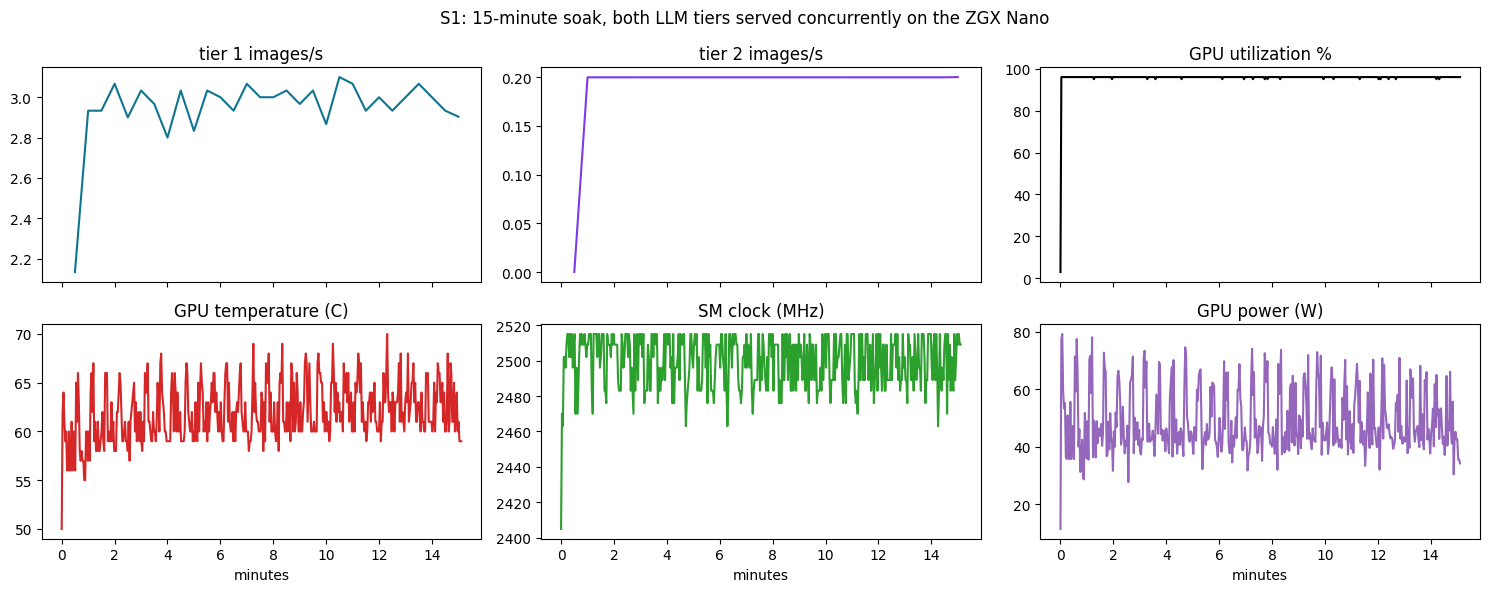

In [13]:
# S1. Soak test
soak_items = random.Random(1).sample(items, min(96, len(items)))
s1, s1w, s1g = stress_llm.soak(t1, t2, refs, soak_items, SOAK_MINUTES)
BENCH["S4_combined_soak"] = s1; print(json.dumps(s1, indent=1))
s1w.to_csv(RESULTS_DIR / "s4_soak_windows.csv", index=False); s1g.to_csv(RESULTS_DIR / "s4_soak_telemetry.csv", index=False)
fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
ax[0, 0].plot(s1w.t_min, s1w.t1_img_per_s, color="#0e7490"); ax[0, 0].set_title("tier 1 images/s")
ax[0, 1].plot(s1w.t_min, s1w.t2_img_per_s, color="#7c3aed"); ax[0, 1].set_title("tier 2 images/s")
ax[0, 2].plot(s1g.t_s / 60, s1g.gpu_util_pct, color="k"); ax[0, 2].set_title("GPU utilization %")
ax[1, 0].plot(s1g.t_s / 60, s1g.temp_c, color="tab:red"); ax[1, 0].set_title("GPU temperature (C)")
ax[1, 1].plot(s1g.t_s / 60, s1g.sm_clock_mhz, color="tab:green"); ax[1, 1].set_title("SM clock (MHz)")
ax[1, 2].plot(s1g.t_s / 60, s1g.power_w, color="tab:purple"); ax[1, 2].set_title("GPU power (W)")
for a in ax[1]: a.set_xlabel("minutes")
plt.suptitle(f"S1: {SOAK_MINUTES:.0f}-minute soak, both LLM tiers served concurrently on the ZGX Nano"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "s4_soak.png", dpi=110); plt.show()

In [14]:
# S2. Energy per inspection
idle_w = telemetry.idle_power(10)
s2 = stress_llm.energy(t1, t2, refs, random.Random(2).sample(items, min(128, len(items))), idle_w)
display(pd.DataFrame(s2).T.astype(float).round(3))
BENCH["S5_energy"] = {k: {kk: round(float(v[kk]), 4) for kk in ("joules_per_item", "items_per_wh", "items_per_s", "mean_gpu_power_w")} for k, v in s2.items()}
BENCH["S5_energy"]["idle_gpu_power_w"] = round(idle_w, 1)

,items,seconds,items_per_s,mean_gpu_power_w,idle_gpu_power_w,joules_per_item,joules_per_item_above_idle,items_per_wh
tier1,128.0,30.07,4.26,58.2,13.8,13.685,10.449,263.063
tier2,48.0,129.45,0.37,45.3,13.8,122.228,85.083,29.453


In [15]:
# S3. Tier-1 robustness (stratified: 10 good + 10 defective per product = 300 images)
rng = random.Random(3); sub = []
for c in CATEGORIES:
    g = [i for i in items if i["category"] == c and i["label"] == 0]; b = [i for i in items if i["category"] == c and i["label"] == 1]
    sub += rng.sample(g, min(10, len(g))) + rng.sample(b, min(10, len(b)))
rob = stress_llm.robustness(t1, sub)
display(rob.round(3)); rob.to_csv(RESULTS_DIR / "s3_robustness_llm.csv", index=False)
BENCH["S3_robustness"] = rob.round(4).to_dict("records")

none: AUC 0.966


darker (x0.6): AUC 0.958


brighter (x1.4): AUC 0.959


blur (r=2): AUC 0.952


JPEG q=30: AUC 0.950


rotate 5 deg: AUC 0.930


,perturbation,roc_auc,recall,false_positive_rate,valid_json_rate
0,none,0.966,0.833,0.027,1.0
1,darker (x0.6),0.958,0.827,0.027,1.0
2,brighter (x1.4),0.959,0.853,0.047,1.0
3,blur (r=2),0.952,0.827,0.040,1.0
4,JPEG q=30,0.950,0.807,0.053,1.0
5,rotate 5 deg,0.930,0.840,0.100,1.0


In [16]:
# S4. Offline proof
s4, attempts = stress_llm.offline_test(run_case, DEMO_CASES)
display(s4)
BENCH["S6_offline"] = {"runs": len(s4), "completed": int(s4.tier1_answered.sum()), "outbound_connection_attempts": len(attempts)}
print(BENCH["S6_offline"], attempts[:5]); assert not attempts and s4.tier1_answered.all()

,case,decision,tier,bucket,seconds,tier1_answered,tier2_answered
0,good part,accept,1,fast_accept,2.20,True,None
1,clear defect,reject,2,agree_defect,13.68,True,True
2,tiers disagree,manual_review,3,t1_flag_t2_good,13.44,True,True


{'runs': 3, 'completed': 3, 'outbound_connection_attempts': 0} []


In [17]:
# S5. Failure recovery: broken inputs must never be accepted; a crashed model server must not crash the line
g0 = splits["bottle"]["eval_good"][0]; d0 = splits["bottle"]["defect_eval"][0]["path"]
s5 = stress_llm.failure_recovery(run_case, config.ARTIFACTS / "failure_inputs", g0, d0, "bottle", t1, t2)
display(s5); s5.to_csv(RESULTS_DIR / "s7_failure_recovery.csv", index=False)
broken = s5[~s5.case.str.contains("server down")]
BENCH["S7_failure_recovery"] = {"cases": len(s5), "broken_inputs_accepted": int((broken.decision == "accept").sum())}
assert BENCH["S7_failure_recovery"]["broken_inputs_accepted"] == 0

,case,decision,reason
0,random bytes,manual_review,unreadable (UnidentifiedImageError)
1,truncated PNG,manual_review,unreadable image (image file is truncated)
2,all-black frame (lens cap),manual_review,image does not look like a bottle from trainin...
3,all-white frame (overexposed),manual_review,image does not look like a bottle from trainin...
4,pure noise,manual_review,image does not look like a bottle from trainin...
5,tier 2 server down (good part),accept,tier 1 is confident the part is good (P(defect...
6,tier 2 server down (defective part),manual_review,"tier 1 flags the part, tier 2 answer unusable;..."
7,tier 1 server down (good part),manual_review,"tier 1 flags the part, tier 2 (27B) sees no de..."
8,tier 1 server down (defective part),reject,tier 1 and tier 2 both see a defect; P(defect)...


## 9. Production-line simulation

scenario,line at 60 parts/min,line at 240 parts/min (overload)
running,False,False
elapsed_s,131.3,97.3
target_parts_per_min,60,240
arrived_per_min,55.3,222.5
decided_per_min,55.3,124.5
parts,121,361
decided,121,202
accepted,114,188
rejected,3,9
manual_review,4,5


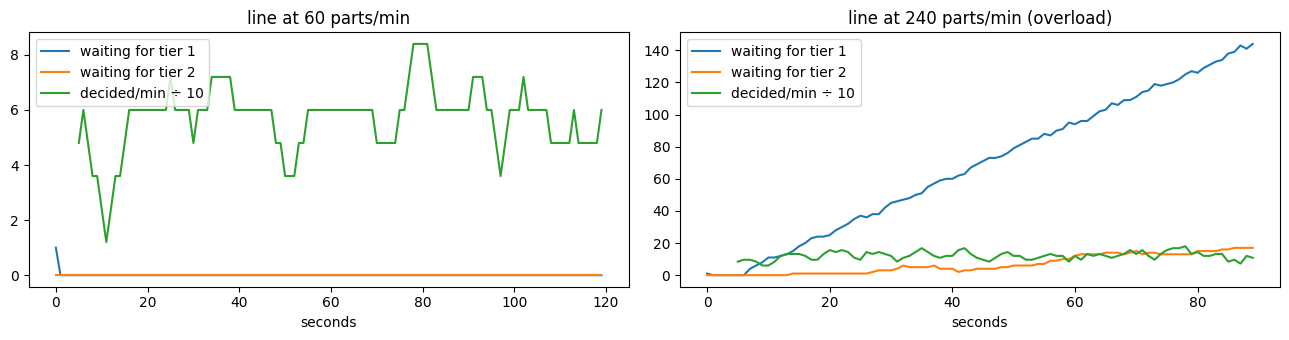

In [18]:
sim_rows, timelines = [], {}
for name, ppm, secs in [("line at 60 parts/min", 60, 120), ("line at 240 parts/min (overload)", 240, 90)]:
    sim = LineSimulator(lambda p, c: t1.safe_ask([p], c), lambda p, c: t2.safe_ask([refs[c], p], c), policy_fn, T_LO, items,
                        parts_per_minute=ppm, defect_rate=0.05, audit_rate=AUDIT, seed=1)
    snap, tl = sim.run_for(secs); sim_rows.append({"scenario": name, **snap}); timelines[name] = tl
line = pd.DataFrame(sim_rows).set_index("scenario").T; display(line)
BENCH["line_simulation"] = {r["scenario"]: r for r in sim_rows}
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
for a, (name, tl) in zip(ax, timelines.items()):
    a.plot(tl.t_s, tl.queue_t1, label="waiting for tier 1"); a.plot(tl.t_s, tl.queue_t2, label="waiting for tier 2")
    a.plot(tl.t_s, tl.decided.diff().rolling(5).mean() * 60 / 10, label="decided/min ÷ 10"); a.set_title(name); a.set_xlabel("seconds"); a.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "line_simulation.png", dpi=110); plt.show()

## 10. Summary for the slides

In [19]:
B = BENCH; Q = {r["config"]: r for r in B["model_quality"]}
T1, Z7, T2, Z27, RN = (Q[k] for k in ["Tier 1: Qwen2.5-VL-7B + LoRA (fine-tuned on Nano)", "Baseline: Qwen2.5-VL-7B zero-shot",
                                       "Tier 2: Qwen3.8-27B with good reference", "Baseline: Qwen3.8-27B zero-shot, single image",
                                       "Baseline: ResNet-18 classifier (non-LLM)"])
H = B["escalation_policy"]["held_out"]; cas = H["NanoInspect cascade"]; hum = H["Human inspects every part"]
sv1 = max(B["serving"]["tier1"], key=lambda r: r["requests_per_s"]); sv2 = max(B["serving"]["tier2"], key=lambda r: r["requests_per_s"])
rows = [
    ("Products / defect types", "15 products, 73 real defect types (MVTec AD), held-out evaluation"),
    ("Tier 1 ROC-AUC · recall (fine-tuned 7B)", f"{T1['roc_auc']:.3f} · {T1['recall']:.1%}   (zero-shot 7B: {Z7['roc_auc']:.3f} · {Z7['recall']:.1%})"),
    ("Tier 1 names the right defect type · location", f"{T1['defect_type_acc']:.1%} · {T1['location_acc']:.1%}"),
    ("Tier 2 ROC-AUC · recall (27B + reference)", f"{T2['roc_auc']:.3f} · {T2['recall']:.1%}   (27B zero-shot: {Z27['roc_auc']:.3f} · {Z27['recall']:.1%})"),
    ("Classical baseline ResNet-18 ROC-AUC · recall", f"{RN['roc_auc']:.3f} · {RN['recall']:.1%} (no defect type or location)"),
    ("LoRA fine-tune on the Nano", f"{B['tier1_finetune']['train_seconds'] / 60:.0f} min, {B['tier1_finetune']['trainable_pct']}% of parameters"),
    ("Serving throughput (vLLM on the Nano)", f"tier 1 {sv1['requests_per_s']} img/s at {sv1['concurrency']} clients · tier 2 {sv2['requests_per_s']} img/s at {sv2['concurrency']} clients"),
    ("Cost per 1,000 parts: cascade vs human inspects all", f"${cas['cost_per_1000_usd']:.2f} vs ${hum['cost_per_1000_usd']:.2f}"),
    ("Per 1,000 parts (cascade)", f"{cas['escapes_per_1000']:.2f} escapes · {cas['false_rejects_per_1000']:.2f} scrapped · {cas['human_reviews_per_1000']:.1f} human reviews · {cas['vlm_calls_per_1000']:.0f} tier-2 calls"),
    (f"Soak {B['S4_combined_soak']['minutes']:.0f} min, both tiers", f"{B['S4_combined_soak']['tier1_inferences']:,} + {B['S4_combined_soak']['tier2_inferences']:,} inferences · max {B['S4_combined_soak']['max_temp_c']:.0f} C · throttling: {B['S4_combined_soak']['throttle_flag_seen']} · errors: {B['S4_combined_soak']['errors']}"),
    ("Energy per inspection (GPU)", f"tier 1 {B['S5_energy']['tier1']['joules_per_item']:.1f} J · tier 2 {B['S5_energy']['tier2']['joules_per_item']:.1f} J"),
    ("Offline (network blocked)", f"{B['S6_offline']['completed']}/{B['S6_offline']['runs']} full inspections, {B['S6_offline']['outbound_connection_attempts']} outbound connection attempts"),
    ("Failure cases", f"{B['S7_failure_recovery']['cases']} tested, {B['S7_failure_recovery']['broken_inputs_accepted']} broken inputs accepted"),
]
slide = pd.DataFrame(rows, columns=["Metric", "Result"]); display(slide)
(RESULTS_DIR / "benchmark_summary.json").write_text(json.dumps(BENCH, indent=1, default=str))
(RESULTS_DIR / "benchmark_table.md").write_text(slide.to_markdown(index=False))
print("Saved", RESULTS_DIR / "benchmark_summary.json")

,Metric,Result
0,Products / defect types,"15 products, 73 real defect types (MVTec AD), ..."
1,Tier 1 ROC-AUC · recall (fine-tuned 7B),0.962 · 84.4% (zero-shot 7B: 0.837 · 20.8%)
2,Tier 1 names the right defect type · location,73.6% · 70.6%
3,Tier 2 ROC-AUC · recall (27B + reference),0.988 · 94.3% (27B zero-shot: 0.924 · 74.7%)
4,Classical baseline ResNet-18 ROC-AUC · recall,0.960 · 92.8% (no defect type or location)
5,LoRA fine-tune on the Nano,"28 min, 0.484% of parameters"
6,Serving throughput (vLLM on the Nano),tier 1 8.36 img/s at 32 clients · tier 2 0.46 ...
7,"Cost per 1,000 parts: cascade vs human inspect...",$411.91 vs $500.00
8,"Per 1,000 parts (cascade)",7.23 escapes · 11.35 scrapped · 55.8 human rev...
9,"Soak 15 min, both tiers","2,671 + 180 inferences · max 70 C · throttling..."


Saved /home/hp14/Downloads/working dir RR/artifacts/results/benchmark_summary.json


## 11. Run the application
```bash
./serve_models.sh both      # tier 1 :8001, tier 2 :8002 (vLLM)
./run_cloud.sh &            # cloud review tier :9000
./run_edge.sh               # operator app :8080  ->  ssh -L 8080:localhost:8080 -L 9000:localhost:9000 <user>@<nano>
```